In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from model.linear_model import LinearModel

import numpy as np
import matplotlib.pyplot as plt

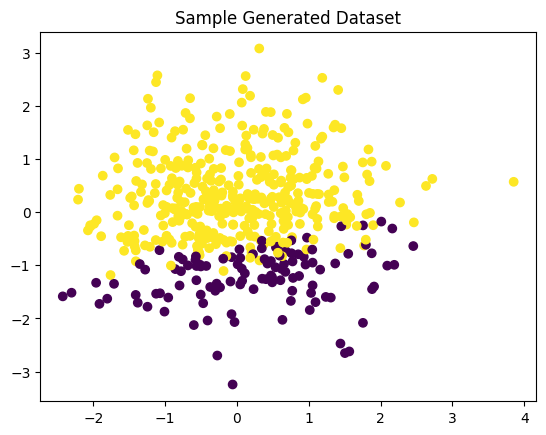

In [3]:
# Sample Code for generating datasets
size = 500
dim = 2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X, y, W = generate_linear_dataset(size, dim, noise_bound=noise_bound, is_reg=False)
plt.scatter(X[:, 1], X[:, 2], c=y)
plt.title("Sample Generated Dataset")
plt.show()

---
## Q2 (a and b) Learning Rate Experiment
---

---
### Dataset A - Load + Setup
---

In [4]:
# Dataset A
loaded_data = np.load('data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset A | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset A | X size : (2000, 3), y size : (2000,)


### Dataset A - Lr Experiments


Dataset A | learning rate = 0.1

50. Training loss: 0.39642646318317665, Val loss:0.3999503724286705
100. Training loss: 0.30671224644883166, Val loss:0.3197720742843507
150. Training loss: 0.26909858066924425, Val loss:0.28587309361947083
200. Training loss: 0.24740444376635967, Val loss:0.2662145731000708
250. Training loss: 0.23295364911701796, Val loss:0.25308573801307876
300. Training loss: 0.22251661594817596, Val loss:0.24359756142057395
350. Training loss: 0.21457468054053055, Val loss:0.2363827590363239
400. Training loss: 0.20830536692093443, Val loss:0.23069682596431643
450. Training loss: 0.20321915761172188, Val loss:0.2260947519940734
500. Training loss: 0.19900426592832746, Val loss:0.22229215201009955


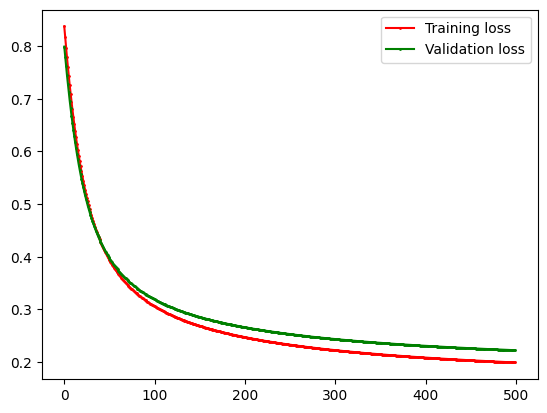

Logistic Regression Evaluation | Dataset A | lr=0.1
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


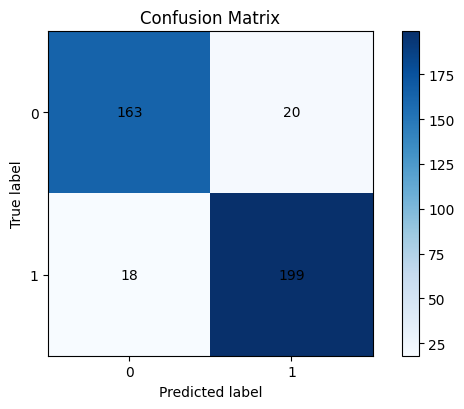

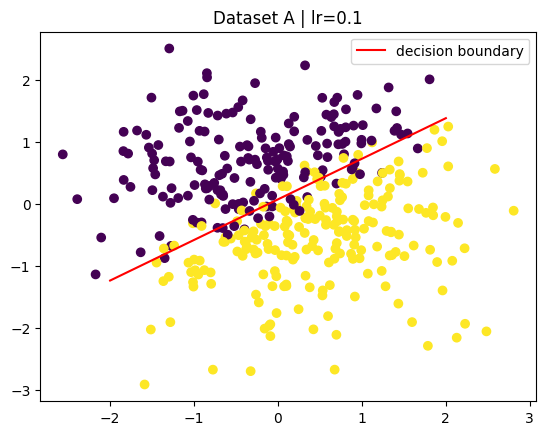


Dataset A | learning rate = 0.01

50. Training loss: 0.745459919917563, Val loss:0.7289685925005063
100. Training loss: 0.6684052041410407, Val loss:0.6557916620079434
150. Training loss: 0.60597131430406, Val loss:0.5968876243482448
200. Training loss: 0.5555295112853988, Val loss:0.549603760496019
250. Training loss: 0.5146553927944149, Val loss:0.5115124405275371
300. Training loss: 0.48129087814211324, Val loss:0.48057462242897986
350. Training loss: 0.4537813804466345, Val loss:0.4551703908054428
400. Training loss: 0.4308398665504119, Val loss:0.4340540530785389
450. Training loss: 0.4114822647561788, Val loss:0.41628271608980655
500. Training loss: 0.39496076529806007, Val loss:0.4011459118872098


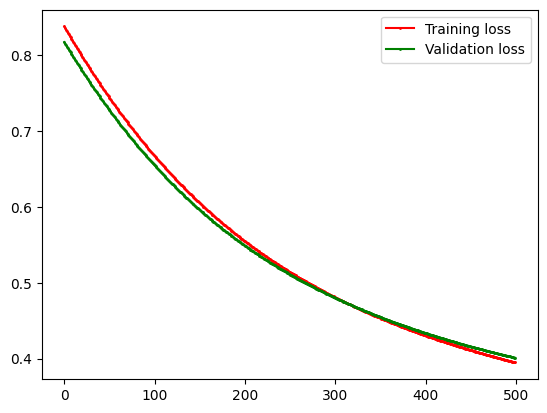

Logistic Regression Evaluation | Dataset A | lr=0.01
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


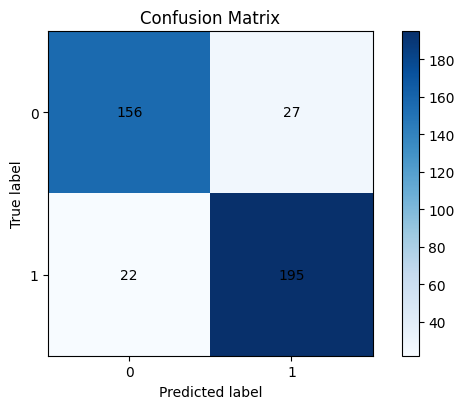

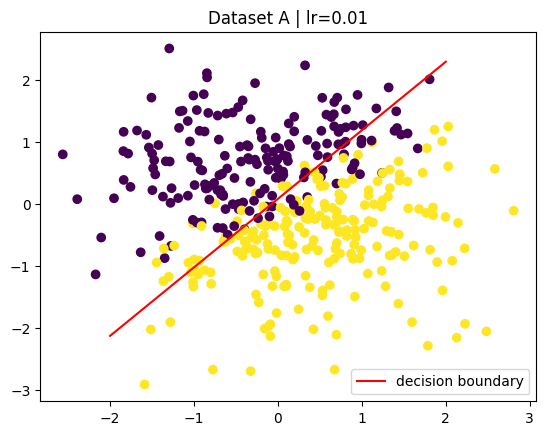


Dataset A | learning rate = 0.001

50. Training loss: 0.8275847287098838, Val loss:0.8091594647385811
100. Training loss: 0.8175637285722182, Val loss:0.7995335011255132
150. Training loss: 0.8077308677313461, Val loss:0.790093128796968
200. Training loss: 0.7980842844658274, Val loss:0.7808364735559051
250. Training loss: 0.7886220349394617, Val loss:0.7717615767769481
300. Training loss: 0.7793420971659509, Val loss:0.762866399529263
350. Training loss: 0.7702423751332139, Val loss:0.7541488268545413
400. Training loss: 0.761320703064522, Val loss:0.745606672178434
450. Training loss: 0.752574849793273, Val loss:0.7372376818334622
500. Training loss: 0.7440025232281375, Val loss:0.7290395396713162


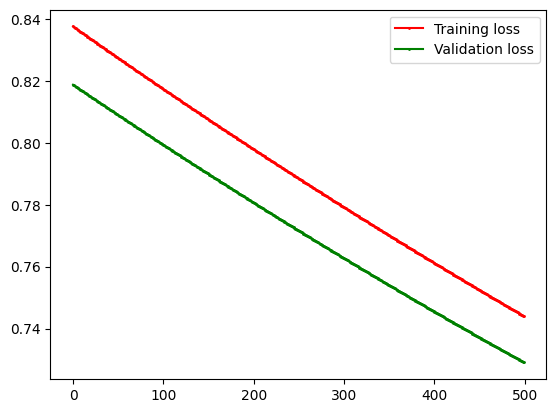

Logistic Regression Evaluation | Dataset A | lr=0.001
Accuracy  : 0.5325
Precision : 0.5676
Recall    : 0.5806
F1-score  : 0.5740


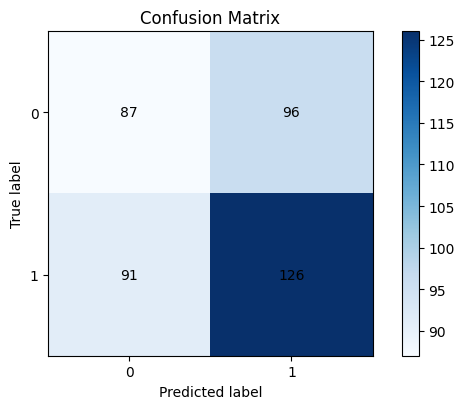

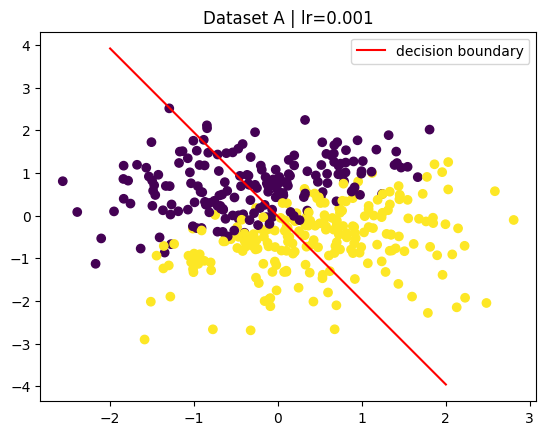

In [5]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset A | learning rate = {lr}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset A | lr={lr}'
    )

    # Optional visualization for 2D datasets
    plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)
    ex1 = np.linspace(-2, 2, 100)
    ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]
    plt.plot(ex1, ex2, color='r', label='decision boundary')
    plt.legend()
    plt.title(f'Dataset A | lr={lr}')
    plt.show()

---
### Dataset B - Load + Setup
---

In [6]:
# Dataset B
loaded_data = np.load('data/logistic_data/logistic_data_B.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset B | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset B | X size : (2000, 3), y size : (2000,)


---
### Dataset B - Lr Experiments
---


Dataset B | learning rate = 0.1

50. Training loss: 0.48589213496840766, Val loss:0.4856088009976395
100. Training loss: 0.4298792421857841, Val loss:0.43135941268546246
150. Training loss: 0.41251332424679044, Val loss:0.41400493812949773
200. Training loss: 0.4049418596868386, Val loss:0.4062849862890238
250. Training loss: 0.40107455931562885, Val loss:0.40227817764527546
300. Training loss: 0.39892162848065726, Val loss:0.40001012083109017
350. Training loss: 0.3976577476635904, Val loss:0.39865193335123866
400. Training loss: 0.3968888555889771, Val loss:0.3978050805663295
450. Training loss: 0.39640908625636667, Val loss:0.39726036565779677
500. Training loss: 0.39610406441207247, Val loss:0.3969010221084003


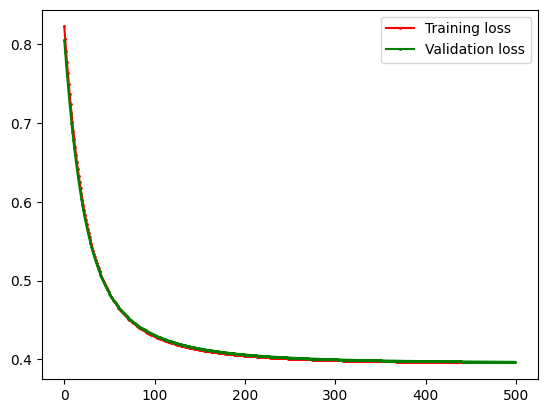

Logistic Regression Evaluation | Dataset B | lr=0.1
Accuracy  : 0.7800
Precision : 0.7793
Recall    : 0.8160
F1-score  : 0.7972


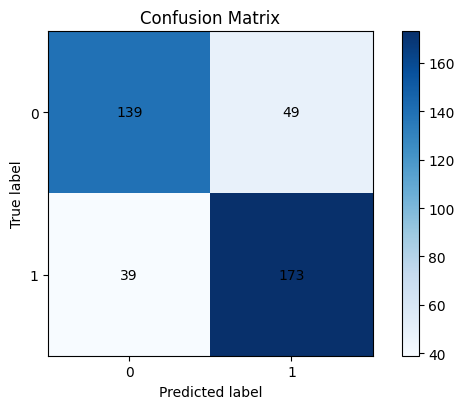

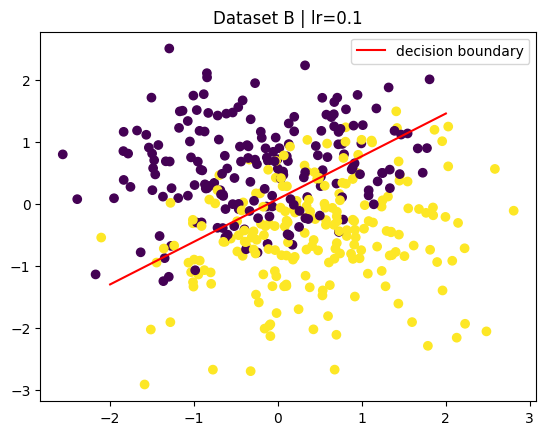


Dataset B | learning rate = 0.01

50. Training loss: 0.7516453713257206, Val loss:0.7487182223498284
100. Training loss: 0.6921523357514527, Val loss:0.6900517425132813
150. Training loss: 0.6438749251561712, Val loss:0.6425491305504548
200. Training loss: 0.6049190182213823, Val loss:0.6042913139944293
250. Training loss: 0.5735143318508558, Val loss:0.5734906364391932
300. Training loss: 0.548122920897773, Val loss:0.5486029025864055
350. Training loss: 0.5274750581419767, Val loss:0.5283621119942427
400. Training loss: 0.5105572588882381, Val loss:0.5117648650887282
450. Training loss: 0.4965769607437512, Val loss:0.4980313878565535
500. Training loss: 0.48492088650898824, Val loss:0.4865613584983862


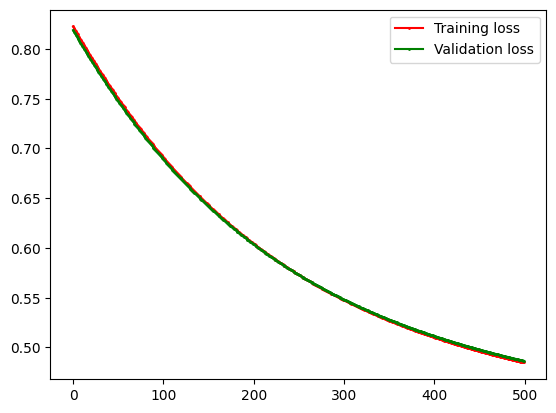

Logistic Regression Evaluation | Dataset B | lr=0.01
Accuracy  : 0.7725
Precision : 0.7689
Recall    : 0.8160
F1-score  : 0.7918


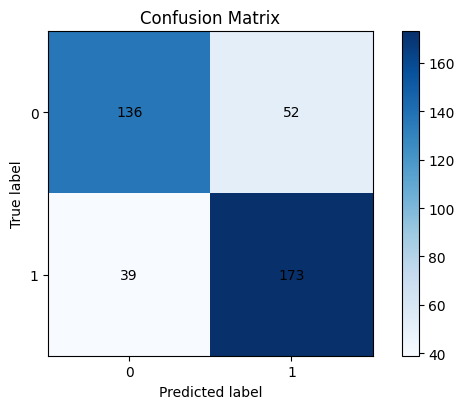

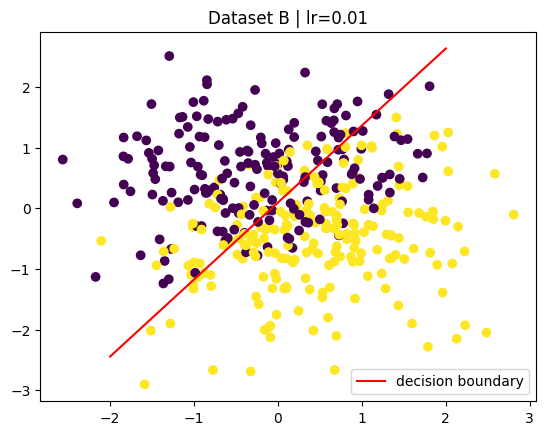


Dataset B | learning rate = 0.001

50. Training loss: 0.814896424272543, Val loss:0.8126060869387274
100. Training loss: 0.8071859503337399, Val loss:0.8049555563431596
150. Training loss: 0.7996183961192862, Val loss:0.7974480748142193
200. Training loss: 0.7921923241989781, Val loss:0.7900822018452955
250. Training loss: 0.7849062485623373, Val loss:0.7828564462445629
300. Training loss: 0.7777586370255671, Val loss:0.7757692686355699
350. Training loss: 0.7707479137088167, Val loss:0.768819084027178
400. Training loss: 0.7638724615730135, Val loss:0.7620042644425986
450. Training loss: 0.7571306250054735, Val loss:0.7553231415972081
500. Training loss: 0.7505207124435194, Val loss:0.7487740096148153


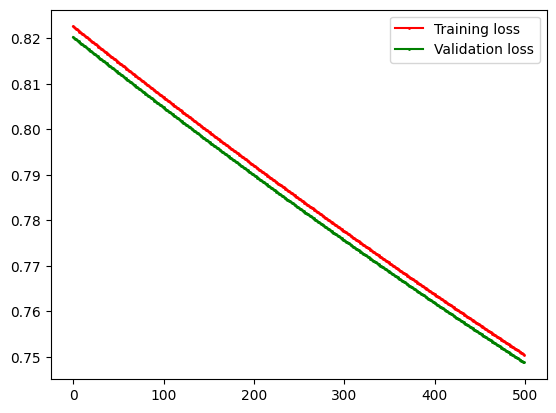

Logistic Regression Evaluation | Dataset B | lr=0.001
Accuracy  : 0.5275
Precision : 0.5516
Recall    : 0.5802
F1-score  : 0.5655


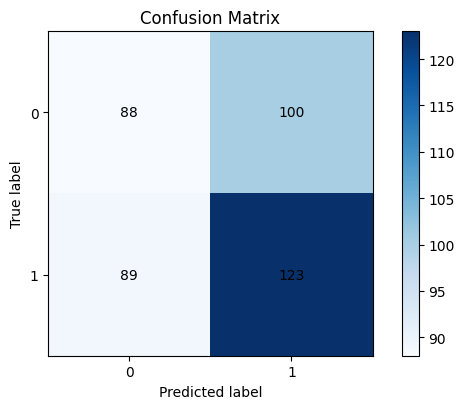

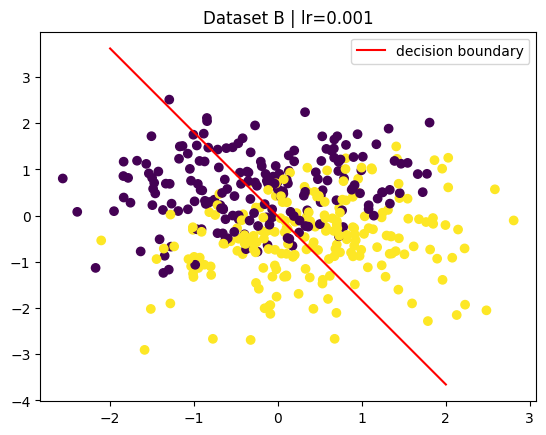

In [7]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset B | learning rate = {lr}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset B | lr={lr}'
    )

    # Optional visualization for 2D datasets
    plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)
    ex1 = np.linspace(-2, 2, 100)
    ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]
    plt.plot(ex1, ex2, color='r', label='decision boundary')
    plt.legend()
    plt.title(f'Dataset B | lr={lr}')
    plt.show()

---
### Dataset C - Load + Setup
---

In [8]:
# Dataset C
loaded_data = np.load('data/logistic_data/logistic_data_C.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset C | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset C | X size : (8000, 6), y size : (8000,)


---
### Dataset C - Lr Experiments
---


Dataset C | learning rate = 0.1

50. Training loss: 0.3186399078221807, Val loss:0.3344772986848749
100. Training loss: 0.2547209057122138, Val loss:0.27234289018461233
150. Training loss: 0.22318004576084718, Val loss:0.24100105688771706
200. Training loss: 0.20300375895693637, Val loss:0.2207243392645836
250. Training loss: 0.1884639317700875, Val loss:0.20600370591397082
300. Training loss: 0.17727132512643784, Val loss:0.19460724269396434
350. Training loss: 0.16828293548069137, Val loss:0.18541137884387757
400. Training loss: 0.16084561890514698, Val loss:0.1777705847092243
450. Training loss: 0.15455185706110755, Val loss:0.17128049308260918
500. Training loss: 0.14913120625945825, Val loss:0.16567189301451823


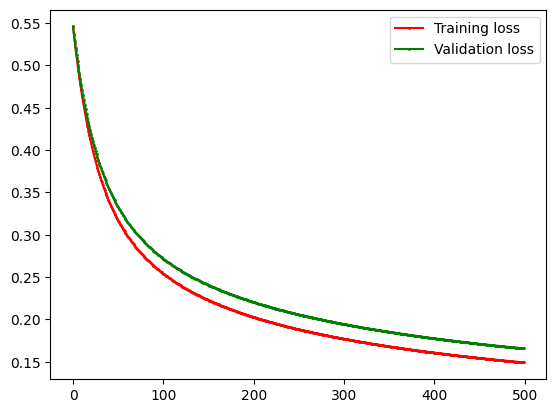

Logistic Regression Evaluation | Dataset C | lr=0.1
Accuracy  : 0.9762
Precision : 0.9852
Recall    : 0.9719
F1-score  : 0.9785


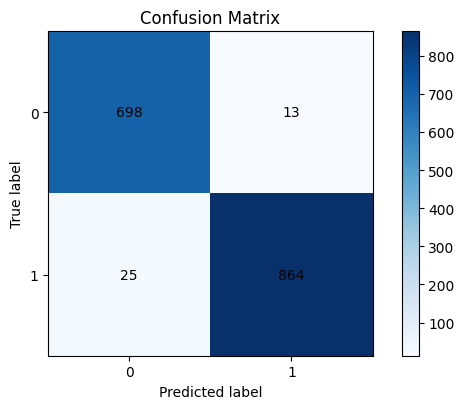


Dataset C | learning rate = 0.01

50. Training loss: 0.5020825116050853, Val loss:0.5128767137471385
100. Training loss: 0.4653828370364316, Val loss:0.47783864428773526
150. Training loss: 0.4348733695964696, Val loss:0.4486311039365397
200. Training loss: 0.4093352777513578, Val loss:0.42411422516449654
250. Training loss: 0.3877843496967376, Val loss:0.4033642541413208
300. Training loss: 0.36943747915251157, Val loss:0.38564523667581596
350. Training loss: 0.3536763685358292, Val loss:0.37037609908534536
400. Training loss: 0.34001422633562706, Val loss:0.3570994602699086
450. Training loss: 0.3280675819752158, Val loss:0.3454549619348448
500. Training loss: 0.31753347329924964, Val loss:0.3351576875262226


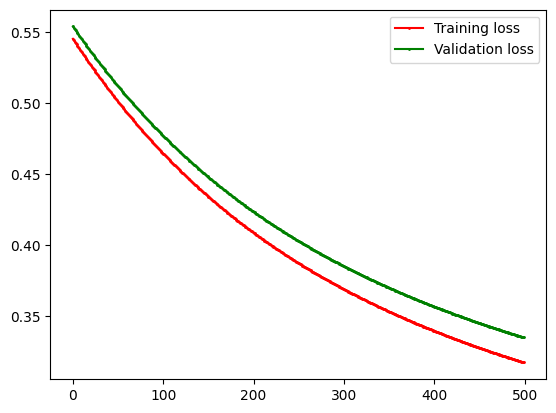

Logistic Regression Evaluation | Dataset C | lr=0.01
Accuracy  : 0.9150
Precision : 0.9353
Recall    : 0.9100
F1-score  : 0.9225


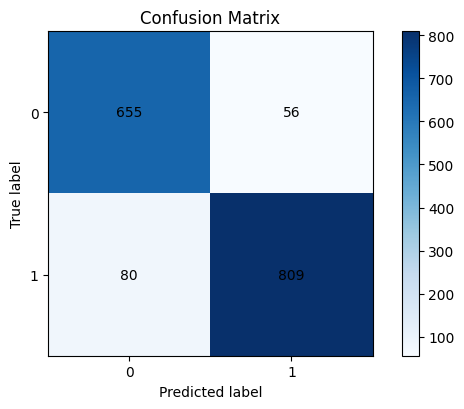


Dataset C | learning rate = 0.001

50. Training loss: 0.5407614751520384, Val loss:0.5505273123034954
100. Training loss: 0.5360453607854162, Val loss:0.5460256405541974
150. Training loss: 0.5314187635089908, Val loss:0.5416082053323188
200. Training loss: 0.5268799166733631, Val loss:0.5372733690067865
250. Training loss: 0.5224270747670345, Val loss:0.5330195131511032
300. Training loss: 0.5180585141479508, Val loss:0.5288450391109123
350. Training loss: 0.5137725337076138, Val loss:0.5247483685248457
400. Training loss: 0.5095674554693967, Val loss:0.5207279437999203
450. Training loss: 0.5054416251228795, Val loss:0.5167822285427481
500. Training loss: 0.5013934124961643, Val loss:0.5129097079478229


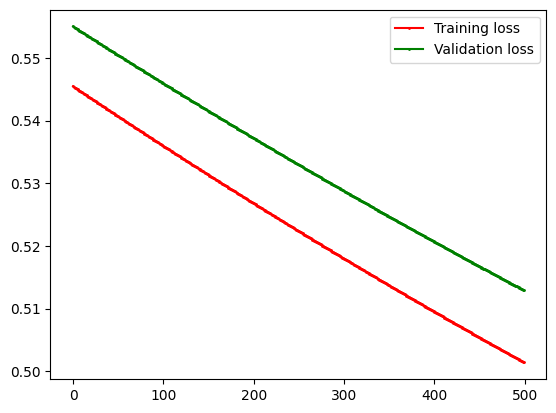

Logistic Regression Evaluation | Dataset C | lr=0.001
Accuracy  : 0.7250
Precision : 0.7761
Recall    : 0.7098
F1-score  : 0.7415


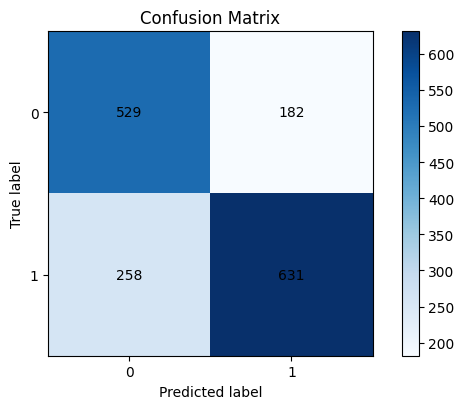

In [9]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset C | learning rate = {lr}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset C | lr={lr}'
    )

---
### Dataset D - Load + Setup
---

In [10]:
# Dataset D
loaded_data = np.load('data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset D | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset D | X size : (8000, 6), y size : (8000,)


---
### Dataset D - Lr Experiments
---


Dataset D | learning rate = 0.1

50. Training loss: 0.33734921986813615, Val loss:0.3492894818231197
100. Training loss: 0.27930058746073855, Val loss:0.2964422584598258
150. Training loss: 0.2518710138697368, Val loss:0.2708356317729795
200. Training loss: 0.23493074654215668, Val loss:0.2547004113219481
250. Training loss: 0.22309044085112176, Val loss:0.2432533086604643
300. Training loss: 0.21423026791605443, Val loss:0.2345934572184955
350. Training loss: 0.20730456831126828, Val loss:0.2277697205498992
400. Training loss: 0.20172171749954612, Val loss:0.22223588752930548
450. Training loss: 0.19711585512236277, Val loss:0.21764953662604497
500. Training loss: 0.19324623897574686, Val loss:0.21378268647513837


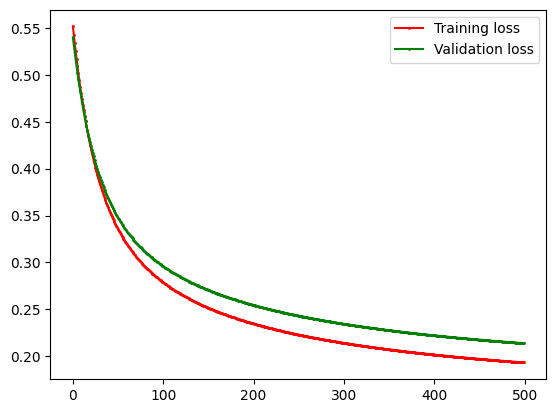

Logistic Regression Evaluation | Dataset D | lr=0.1
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


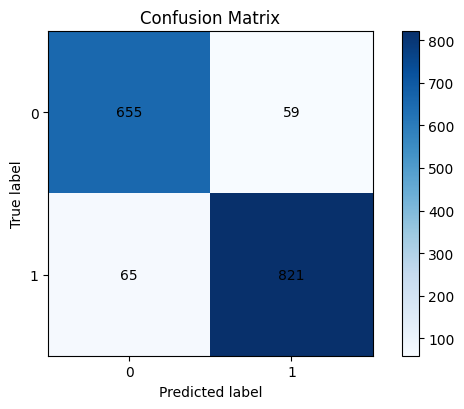


Dataset D | learning rate = 0.01

50. Training loss: 0.510428474536956, Val loss:0.5096830037085237
100. Training loss: 0.475572188153663, Val loss:0.4776817269491726
150. Training loss: 0.44662948900734395, Val loss:0.4511228642557118
200. Training loss: 0.4224465519218822, Val loss:0.42893988060421745
250. Training loss: 0.4020880450778015, Val loss:0.41026719448247295
300. Training loss: 0.3848069814383682, Val loss:0.3944142692703644
350. Training loss: 0.37001160745178474, Val loss:0.3808353870901958
400. Training loss: 0.35723469403555763, Val loss:0.36910084303078516
450. Training loss: 0.34610731256181787, Val loss:0.3588721657815527
500. Training loss: 0.3363374478661988, Val loss:0.34988196189733695


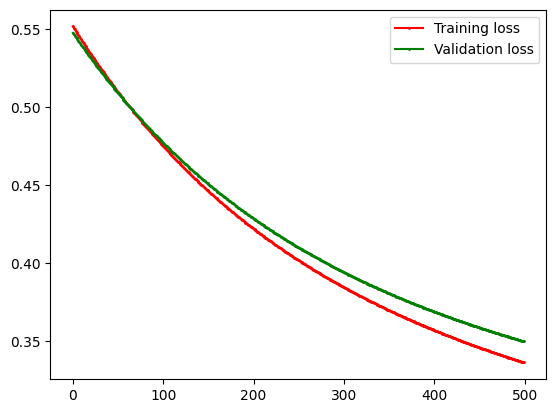

Logistic Regression Evaluation | Dataset D | lr=0.01
Accuracy  : 0.8775
Precision : 0.8984
Recall    : 0.8781
F1-score  : 0.8881


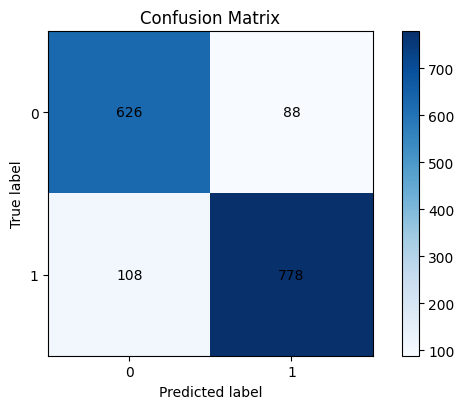


Dataset D | learning rate = 0.001

50. Training loss: 0.547185628855743, Val loss:0.544194683184311
100. Training loss: 0.5427033545416547, Val loss:0.540062799582439
150. Training loss: 0.5383062365853594, Val loss:0.5360095740536133
200. Training loss: 0.5339926138483151, Val loss:0.5320334762013885
250. Training loss: 0.5297608447934081, Val loss:0.5281329937012951
300. Training loss: 0.5256093081462847, Val loss:0.5243066328008659
350. Training loss: 0.5215364034967234, Val loss:0.5205529187783371
400. Training loss: 0.517540551841485, Val loss:0.5168703963611139
450. Training loss: 0.5136201960702322, Val loss:0.5132576301051055
500. Training loss: 0.509773801396239, Val loss:0.5097132047360233


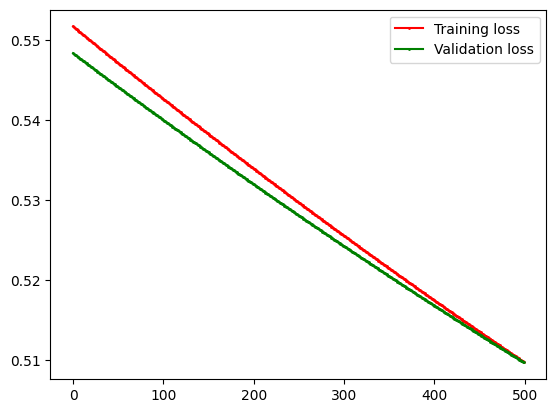

Logistic Regression Evaluation | Dataset D | lr=0.001
Accuracy  : 0.7169
Precision : 0.7670
Recall    : 0.7020
F1-score  : 0.7331


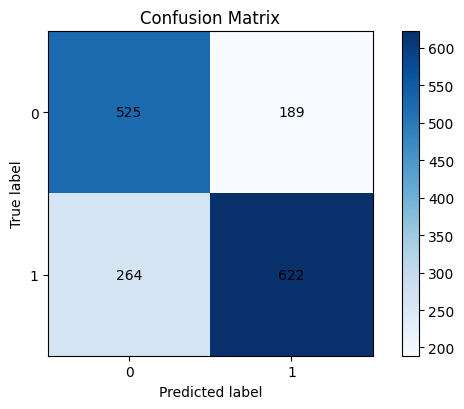

In [11]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset D | learning rate = {lr}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset D | lr={lr}'
    )

---
## Q2 (d and e) - Iteration Experiment
---

---
### Dataset A - Load + Setup
---

In [12]:
# Dataset A for iteration experiment
loaded_data = np.load('data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset A | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset A | X size : (2000, 3), y size : (2000,)


---
### Dataset A - Iteration Experiments
---


Dataset A | n_iteration = 500

50. Training loss: 0.745459919917563, Val loss:0.7289685925005063
100. Training loss: 0.6684052041410407, Val loss:0.6557916620079434
150. Training loss: 0.60597131430406, Val loss:0.5968876243482448
200. Training loss: 0.5555295112853988, Val loss:0.549603760496019
250. Training loss: 0.5146553927944149, Val loss:0.5115124405275371
300. Training loss: 0.48129087814211324, Val loss:0.48057462242897986
350. Training loss: 0.4537813804466345, Val loss:0.4551703908054428
400. Training loss: 0.4308398665504119, Val loss:0.4340540530785389
450. Training loss: 0.4114822647561788, Val loss:0.41628271608980655
500. Training loss: 0.39496076529806007, Val loss:0.4011459118872098


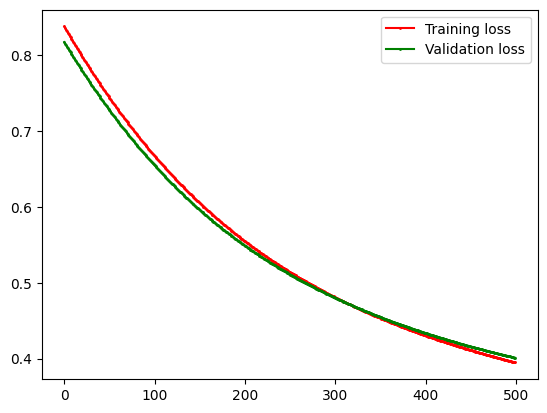

Logistic Regression Evaluation | Dataset A | n_iteration=500
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


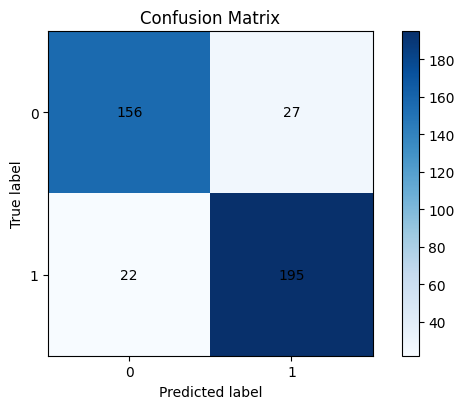

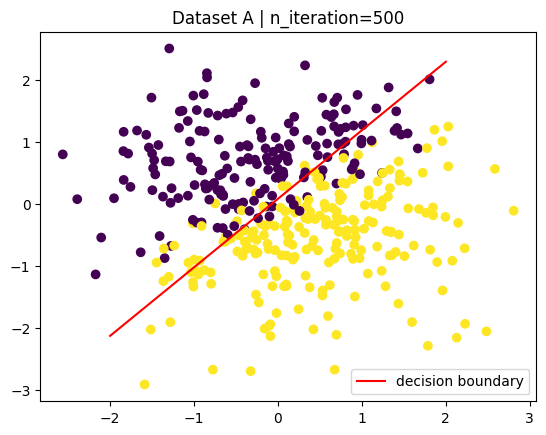


Dataset A | n_iteration = 1000

50. Training loss: 0.745459919917563, Val loss:0.7289685925005063
100. Training loss: 0.6684052041410407, Val loss:0.6557916620079434
150. Training loss: 0.60597131430406, Val loss:0.5968876243482448
200. Training loss: 0.5555295112853988, Val loss:0.549603760496019
250. Training loss: 0.5146553927944149, Val loss:0.5115124405275371
300. Training loss: 0.48129087814211324, Val loss:0.48057462242897986
350. Training loss: 0.4537813804466345, Val loss:0.4551703908054428
400. Training loss: 0.4308398665504119, Val loss:0.4340540530785389
450. Training loss: 0.4114822647561788, Val loss:0.41628271608980655
500. Training loss: 0.39496076529806007, Val loss:0.4011459118872098
550. Training loss: 0.38070649694108866, Val loss:0.38810694618343644
600. Training loss: 0.3682843359571, Val loss:0.3767576738805937
650. Training loss: 0.3573587886372804, Val loss:0.36678491462705176
700. Training loss: 0.34766875899093364, Val loss:0.3579459245645621
750. Training l

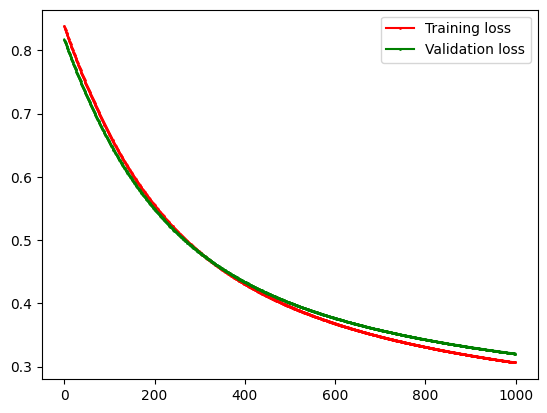

Logistic Regression Evaluation | Dataset A | n_iteration=1000
Accuracy  : 0.9025
Precision : 0.9045
Recall    : 0.9171
F1-score  : 0.9108


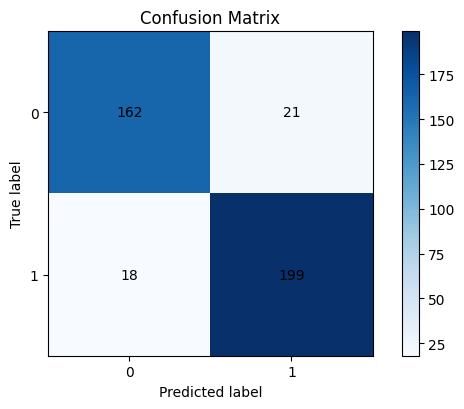

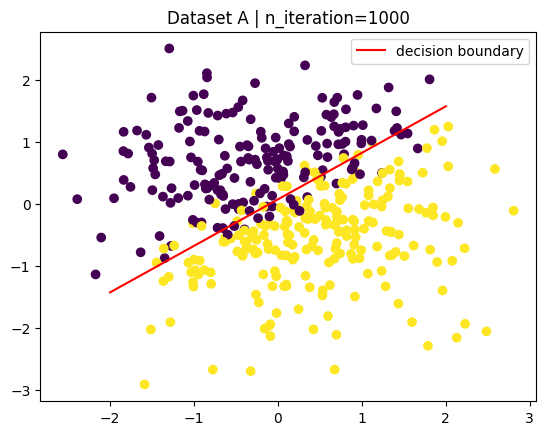


Dataset A | n_iteration = 1500

50. Training loss: 0.745459919917563, Val loss:0.7289685925005063
100. Training loss: 0.6684052041410407, Val loss:0.6557916620079434
150. Training loss: 0.60597131430406, Val loss:0.5968876243482448
200. Training loss: 0.5555295112853988, Val loss:0.549603760496019
250. Training loss: 0.5146553927944149, Val loss:0.5115124405275371
300. Training loss: 0.48129087814211324, Val loss:0.48057462242897986
350. Training loss: 0.4537813804466345, Val loss:0.4551703908054428
400. Training loss: 0.4308398665504119, Val loss:0.4340540530785389
450. Training loss: 0.4114822647561788, Val loss:0.41628271608980655
500. Training loss: 0.39496076529806007, Val loss:0.4011459118872098
550. Training loss: 0.38070649694108866, Val loss:0.38810694618343644
600. Training loss: 0.3682843359571, Val loss:0.3767576738805937
650. Training loss: 0.3573587886372804, Val loss:0.36678491462705176
700. Training loss: 0.34766875899093364, Val loss:0.3579459245645621
750. Training l

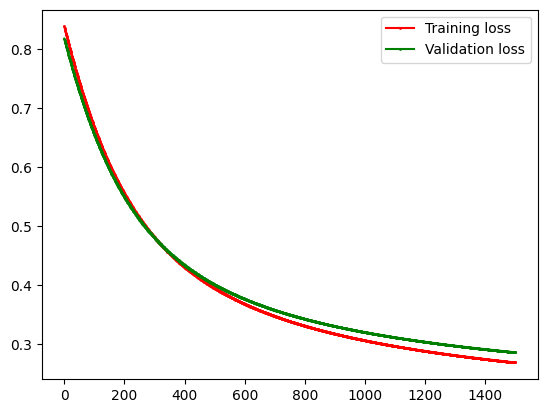

Logistic Regression Evaluation | Dataset A | n_iteration=1500
Accuracy  : 0.9025
Precision : 0.9083
Recall    : 0.9124
F1-score  : 0.9103


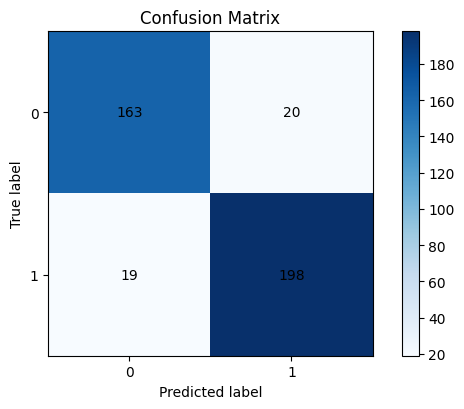

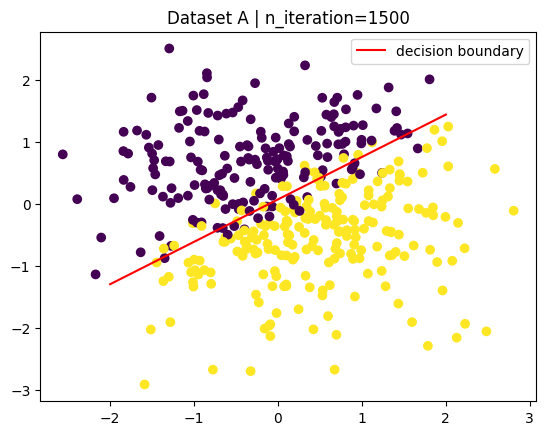

In [13]:
for n_iter in [500, 1000, 1500]:
    print("\n" + "=" * 80)
    print(f"Dataset A | n_iteration = {n_iter}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=0.01, n_iteration=n_iter, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset A | n_iteration={n_iter}'
    )

    # Optional visualization for 2D datasets
    plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)
    ex1 = np.linspace(-2, 2, 100)
    ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]
    plt.plot(ex1, ex2, color='r', label='decision boundary')
    plt.legend()
    plt.title(f'Dataset A | n_iteration={n_iter}')
    plt.show()

---
### Dataset B - Load + Setup
---

In [14]:
# Dataset B for iteration experiment
loaded_data = np.load('data/logistic_data/logistic_data_B.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset B | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset B | X size : (2000, 3), y size : (2000,)


---
### Dataset B - Iteration Experiments
---


Dataset B | n_iteration = 500

50. Training loss: 0.7516453713257206, Val loss:0.7487182223498284
100. Training loss: 0.6921523357514527, Val loss:0.6900517425132813
150. Training loss: 0.6438749251561712, Val loss:0.6425491305504548
200. Training loss: 0.6049190182213823, Val loss:0.6042913139944293
250. Training loss: 0.5735143318508558, Val loss:0.5734906364391932
300. Training loss: 0.548122920897773, Val loss:0.5486029025864055
350. Training loss: 0.5274750581419767, Val loss:0.5283621119942427
400. Training loss: 0.5105572588882381, Val loss:0.5117648650887282
450. Training loss: 0.4965769607437512, Val loss:0.4980313878565535
500. Training loss: 0.48492088650898824, Val loss:0.4865613584983862


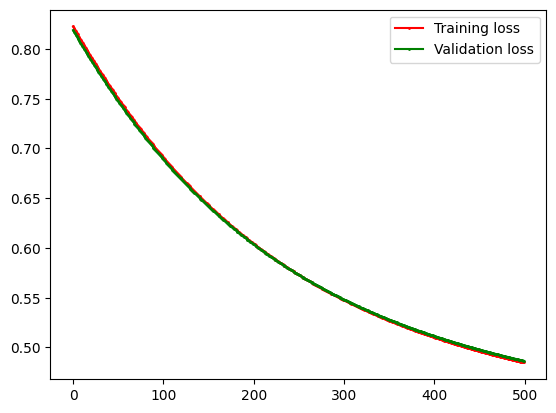

Logistic Regression Evaluation | Dataset B | n_iteration=500
Accuracy  : 0.7725
Precision : 0.7689
Recall    : 0.8160
F1-score  : 0.7918


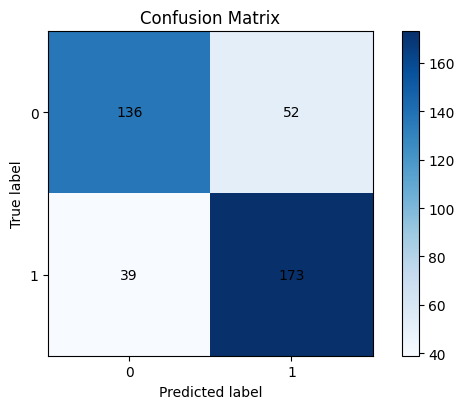

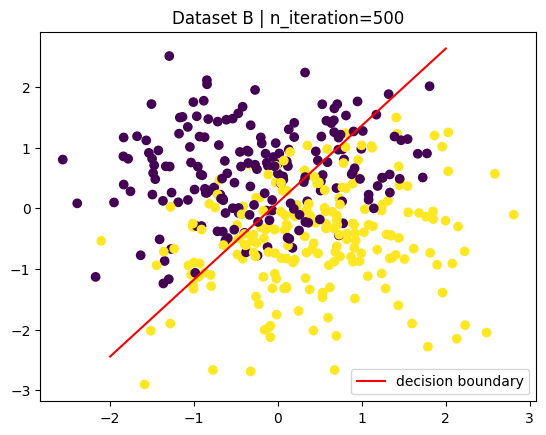


Dataset B | n_iteration = 1000

50. Training loss: 0.7516453713257206, Val loss:0.7487182223498284
100. Training loss: 0.6921523357514527, Val loss:0.6900517425132813
150. Training loss: 0.6438749251561712, Val loss:0.6425491305504548
200. Training loss: 0.6049190182213823, Val loss:0.6042913139944293
250. Training loss: 0.5735143318508558, Val loss:0.5734906364391932
300. Training loss: 0.548122920897773, Val loss:0.5486029025864055
350. Training loss: 0.5274750581419767, Val loss:0.5283621119942427
400. Training loss: 0.5105572588882381, Val loss:0.5117648650887282
450. Training loss: 0.4965769607437512, Val loss:0.4980313878565535
500. Training loss: 0.48492088650898824, Val loss:0.4865613584983862
550. Training loss: 0.4751161732728728, Val loss:0.47689368493512296
600. Training loss: 0.4667977913288757, Val loss:0.4686734023795897
650. Training loss: 0.4596827548352322, Val loss:0.4616258291382497
700. Training loss: 0.4535503334536467, Val loss:0.4555369405660385
750. Training l

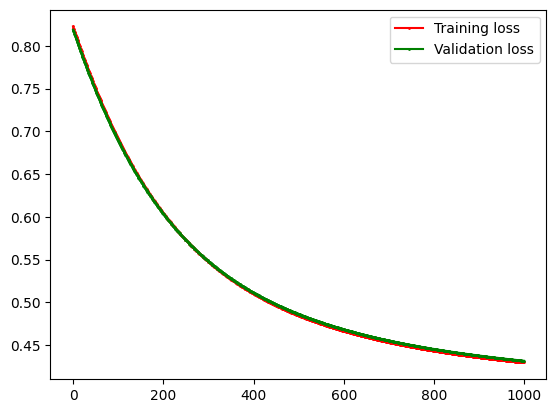

Logistic Regression Evaluation | Dataset B | n_iteration=1000
Accuracy  : 0.7750
Precision : 0.7748
Recall    : 0.8113
F1-score  : 0.7926


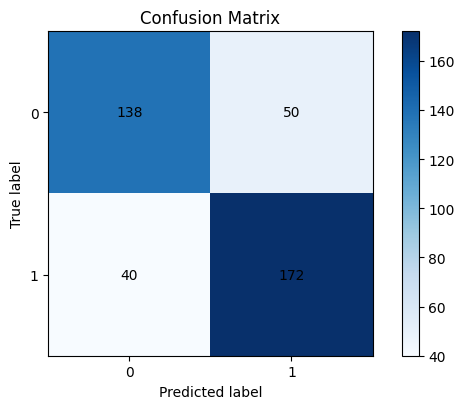

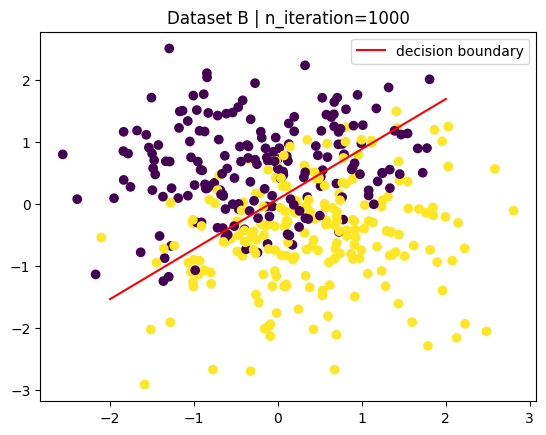


Dataset B | n_iteration = 1500

50. Training loss: 0.7516453713257206, Val loss:0.7487182223498284
100. Training loss: 0.6921523357514527, Val loss:0.6900517425132813
150. Training loss: 0.6438749251561712, Val loss:0.6425491305504548
200. Training loss: 0.6049190182213823, Val loss:0.6042913139944293
250. Training loss: 0.5735143318508558, Val loss:0.5734906364391932
300. Training loss: 0.548122920897773, Val loss:0.5486029025864055
350. Training loss: 0.5274750581419767, Val loss:0.5283621119942427
400. Training loss: 0.5105572588882381, Val loss:0.5117648650887282
450. Training loss: 0.4965769607437512, Val loss:0.4980313878565535
500. Training loss: 0.48492088650898824, Val loss:0.4865613584983862
550. Training loss: 0.4751161732728728, Val loss:0.47689368493512296
600. Training loss: 0.4667977913288757, Val loss:0.4686734023795897
650. Training loss: 0.4596827548352322, Val loss:0.4616258291382497
700. Training loss: 0.4535503334536467, Val loss:0.4555369405660385
750. Training l

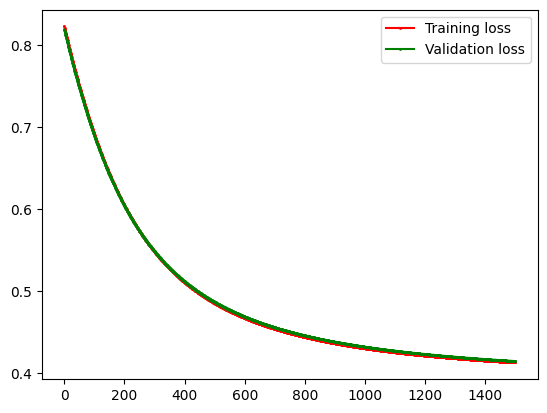

Logistic Regression Evaluation | Dataset B | n_iteration=1500
Accuracy  : 0.7775
Precision : 0.7783
Recall    : 0.8113
F1-score  : 0.7945


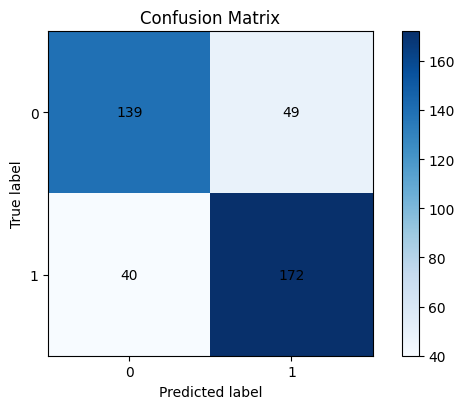

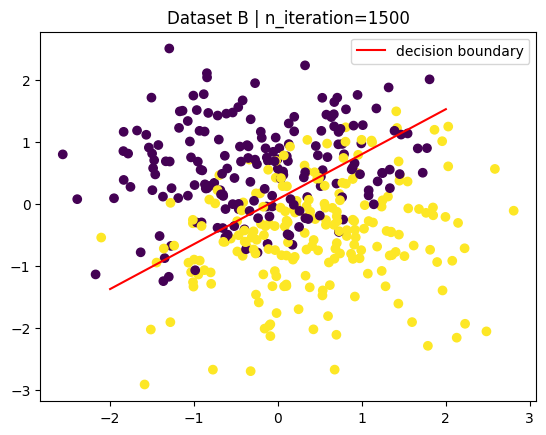

In [15]:
for n_iter in [500, 1000, 1500]:
    print("\n" + "=" * 80)
    print(f"Dataset B | n_iteration = {n_iter}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=0.01, n_iteration=n_iter, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset B | n_iteration={n_iter}'
    )

    # Optional visualization for 2D datasets
    plt.scatter(X_val[:, 1], X_val[:, 2], c=y_val)
    ex1 = np.linspace(-2, 2, 100)
    ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]
    plt.plot(ex1, ex2, color='r', label='decision boundary')
    plt.legend()
    plt.title(f'Dataset B | n_iteration={n_iter}')
    plt.show()

---
### Dataset C - Load + Setup
---

In [16]:
# Dataset C for iteration experiment
loaded_data = np.load('data/logistic_data/logistic_data_C.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset C | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset C | X size : (8000, 6), y size : (8000,)


---
### Dataset C - Iteration Experiments
---


Dataset C | n_iteration = 500

50. Training loss: 0.5020825116050853, Val loss:0.5128767137471385
100. Training loss: 0.4653828370364316, Val loss:0.47783864428773526
150. Training loss: 0.4348733695964696, Val loss:0.4486311039365397
200. Training loss: 0.4093352777513578, Val loss:0.42411422516449654
250. Training loss: 0.3877843496967376, Val loss:0.4033642541413208
300. Training loss: 0.36943747915251157, Val loss:0.38564523667581596
350. Training loss: 0.3536763685358292, Val loss:0.37037609908534536
400. Training loss: 0.34001422633562706, Val loss:0.3570994602699086
450. Training loss: 0.3280675819752158, Val loss:0.3454549619348448
500. Training loss: 0.31753347329924964, Val loss:0.3351576875262226


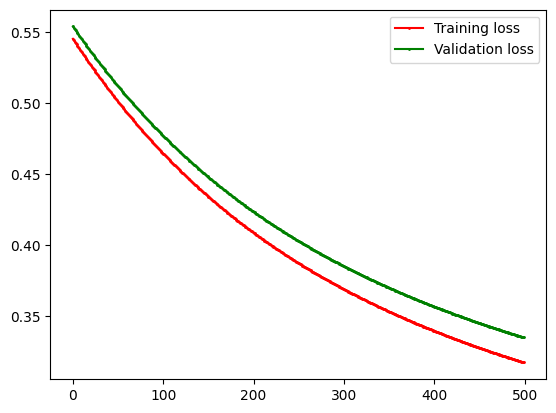

Logistic Regression Evaluation | Dataset C | n_iteration=500
Accuracy  : 0.9150
Precision : 0.9353
Recall    : 0.9100
F1-score  : 0.9225


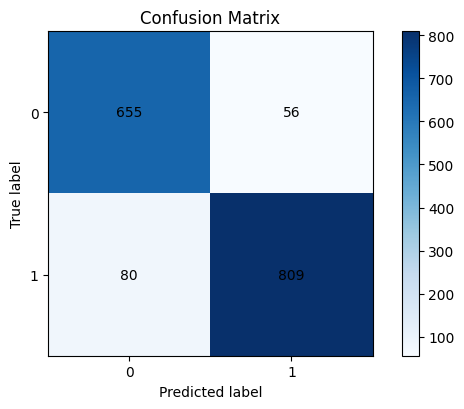


Dataset C | n_iteration = 1000

50. Training loss: 0.5020825116050853, Val loss:0.5128767137471385
100. Training loss: 0.4653828370364316, Val loss:0.47783864428773526
150. Training loss: 0.4348733695964696, Val loss:0.4486311039365397
200. Training loss: 0.4093352777513578, Val loss:0.42411422516449654
250. Training loss: 0.3877843496967376, Val loss:0.4033642541413208
300. Training loss: 0.36943747915251157, Val loss:0.38564523667581596
350. Training loss: 0.3536763685358292, Val loss:0.37037609908534536
400. Training loss: 0.34001422633562706, Val loss:0.3570994602699086
450. Training loss: 0.3280675819752158, Val loss:0.3454549619348448
500. Training loss: 0.31753347329924964, Val loss:0.3351576875262226
550. Training loss: 0.30817145666330903, Val loss:0.3259812138404762
600. Training loss: 0.29978963305824013, Val loss:0.31774450745473726
650. Training loss: 0.29223388215910806, Val loss:0.3103018670523106
700. Training loss: 0.2853795969138649, Val loss:0.3035352203465706
750. 

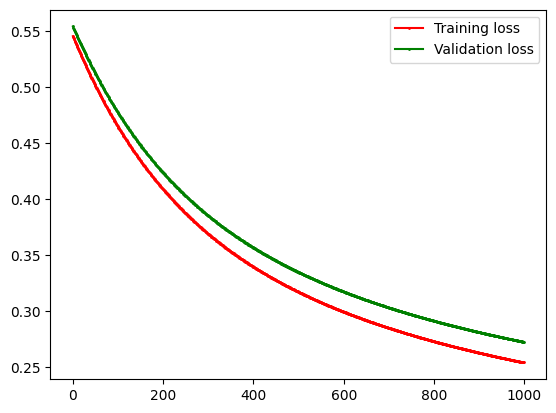

Logistic Regression Evaluation | Dataset C | n_iteration=1000
Accuracy  : 0.9594
Precision : 0.9703
Recall    : 0.9561
F1-score  : 0.9632


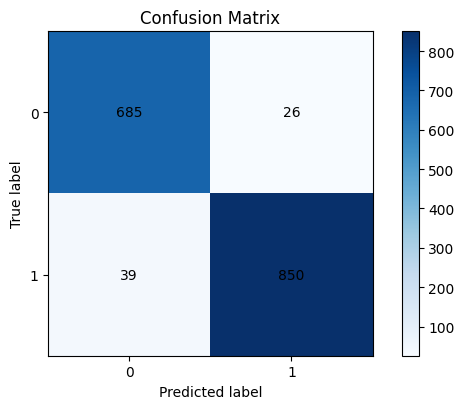


Dataset C | n_iteration = 1500

50. Training loss: 0.5020825116050853, Val loss:0.5128767137471385
100. Training loss: 0.4653828370364316, Val loss:0.47783864428773526
150. Training loss: 0.4348733695964696, Val loss:0.4486311039365397
200. Training loss: 0.4093352777513578, Val loss:0.42411422516449654
250. Training loss: 0.3877843496967376, Val loss:0.4033642541413208
300. Training loss: 0.36943747915251157, Val loss:0.38564523667581596
350. Training loss: 0.3536763685358292, Val loss:0.37037609908534536
400. Training loss: 0.34001422633562706, Val loss:0.3570994602699086
450. Training loss: 0.3280675819752158, Val loss:0.3454549619348448
500. Training loss: 0.31753347329924964, Val loss:0.3351576875262226
550. Training loss: 0.30817145666330903, Val loss:0.3259812138404762
600. Training loss: 0.29978963305824013, Val loss:0.31774450745473726
650. Training loss: 0.29223388215910806, Val loss:0.3103018670523106
700. Training loss: 0.2853795969138649, Val loss:0.3035352203465706
750. 

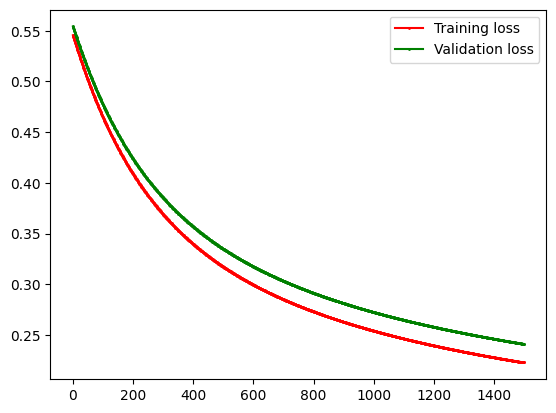

Logistic Regression Evaluation | Dataset C | n_iteration=1500
Accuracy  : 0.9762
Precision : 0.9863
Recall    : 0.9708
F1-score  : 0.9785


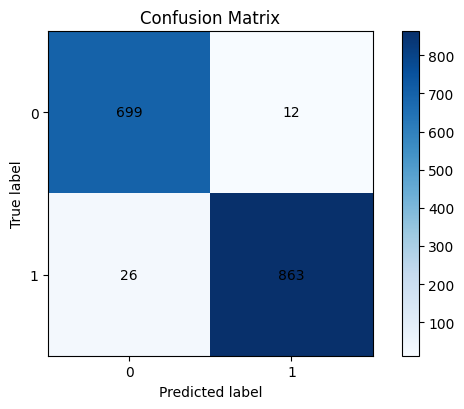

In [17]:
for n_iter in [500, 1000, 1500]:
    print("\n" + "=" * 80)
    print(f"Dataset C | n_iteration = {n_iter}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=0.01, n_iteration=n_iter, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset C | n_iteration={n_iter}'
    )

---
### Dataset D - Load + Setup
---

In [18]:
# Dataset D for iteration experiment
loaded_data = np.load('data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset D | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset D | X size : (8000, 6), y size : (8000,)


---
### Dataset D - Iteration Experiments
---


Dataset D | n_iteration = 500

50. Training loss: 0.510428474536956, Val loss:0.5096830037085237
100. Training loss: 0.475572188153663, Val loss:0.4776817269491726
150. Training loss: 0.44662948900734395, Val loss:0.4511228642557118
200. Training loss: 0.4224465519218822, Val loss:0.42893988060421745
250. Training loss: 0.4020880450778015, Val loss:0.41026719448247295
300. Training loss: 0.3848069814383682, Val loss:0.3944142692703644
350. Training loss: 0.37001160745178474, Val loss:0.3808353870901958
400. Training loss: 0.35723469403555763, Val loss:0.36910084303078516
450. Training loss: 0.34610731256181787, Val loss:0.3588721657815527
500. Training loss: 0.3363374478661988, Val loss:0.34988196189733695


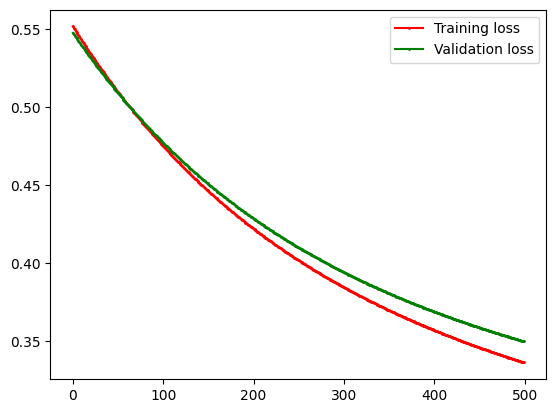

Logistic Regression Evaluation | Dataset D | n_iteration=500
Accuracy  : 0.8775
Precision : 0.8984
Recall    : 0.8781
F1-score  : 0.8881


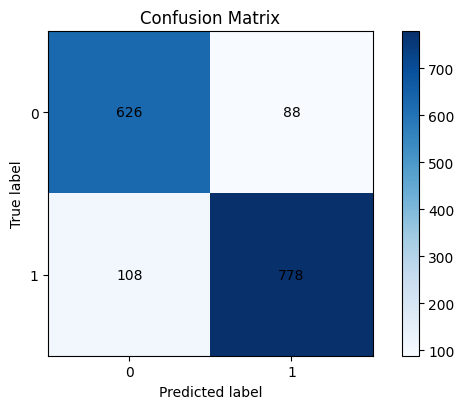


Dataset D | n_iteration = 1000

50. Training loss: 0.510428474536956, Val loss:0.5096830037085237
100. Training loss: 0.475572188153663, Val loss:0.4776817269491726
150. Training loss: 0.44662948900734395, Val loss:0.4511228642557118
200. Training loss: 0.4224465519218822, Val loss:0.42893988060421745
250. Training loss: 0.4020880450778015, Val loss:0.41026719448247295
300. Training loss: 0.3848069814383682, Val loss:0.3944142692703644
350. Training loss: 0.37001160745178474, Val loss:0.3808353870901958
400. Training loss: 0.35723469403555763, Val loss:0.36910084303078516
450. Training loss: 0.34610731256181787, Val loss:0.3588721657815527
500. Training loss: 0.3363374478661988, Val loss:0.34988196189733695
550. Training loss: 0.32769302298007397, Val loss:0.34191801918859355
600. Training loss: 0.31998864035016356, Val loss:0.33481097487299777
650. Training loss: 0.3130753186253522, Val loss:0.32842482578799465
700. Training loss: 0.30683258165267435, Val loss:0.3226496464272412
750.

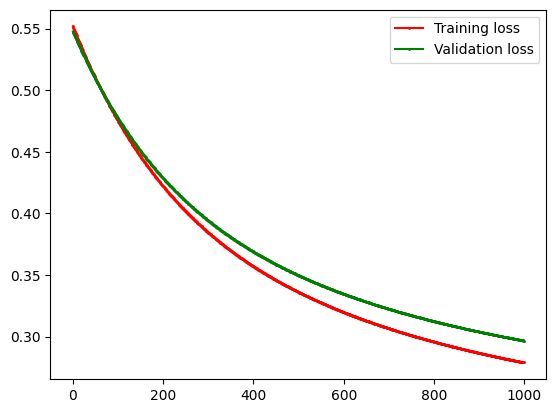

Logistic Regression Evaluation | Dataset D | n_iteration=1000
Accuracy  : 0.9187
Precision : 0.9305
Recall    : 0.9221
F1-score  : 0.9263


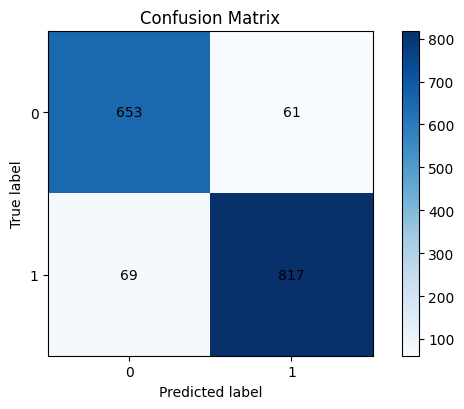


Dataset D | n_iteration = 1500

50. Training loss: 0.510428474536956, Val loss:0.5096830037085237
100. Training loss: 0.475572188153663, Val loss:0.4776817269491726
150. Training loss: 0.44662948900734395, Val loss:0.4511228642557118
200. Training loss: 0.4224465519218822, Val loss:0.42893988060421745
250. Training loss: 0.4020880450778015, Val loss:0.41026719448247295
300. Training loss: 0.3848069814383682, Val loss:0.3944142692703644
350. Training loss: 0.37001160745178474, Val loss:0.3808353870901958
400. Training loss: 0.35723469403555763, Val loss:0.36910084303078516
450. Training loss: 0.34610731256181787, Val loss:0.3588721657815527
500. Training loss: 0.3363374478661988, Val loss:0.34988196189733695
550. Training loss: 0.32769302298007397, Val loss:0.34191801918859355
600. Training loss: 0.31998864035016356, Val loss:0.33481097487299777
650. Training loss: 0.3130753186253522, Val loss:0.32842482578799465
700. Training loss: 0.30683258165267435, Val loss:0.3226496464272412
750.

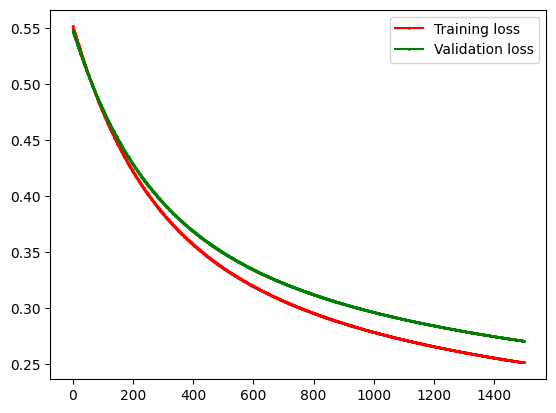

Logistic Regression Evaluation | Dataset D | n_iteration=1500
Accuracy  : 0.9231
Precision : 0.9360
Recall    : 0.9244
F1-score  : 0.9302


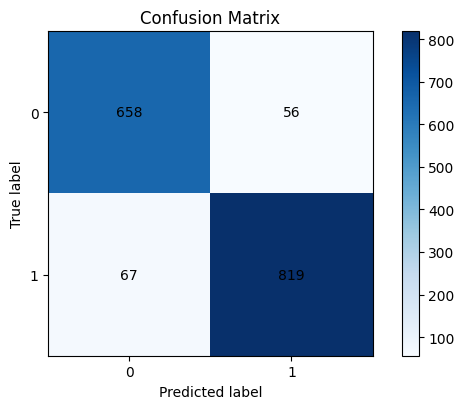

In [19]:
for n_iter in [500, 1000, 1500]:
    print("\n" + "=" * 80)
    print(f"Dataset D | n_iteration = {n_iter}")
    print("\n" + "=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
    model.fit(X_train, y_train, lr=0.01, n_iteration=n_iter, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_binary_classifier(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Logistic Regression Evaluation | Dataset D | n_iteration={n_iter}'
    )